<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/Changbal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1-3950470582.py:68: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.

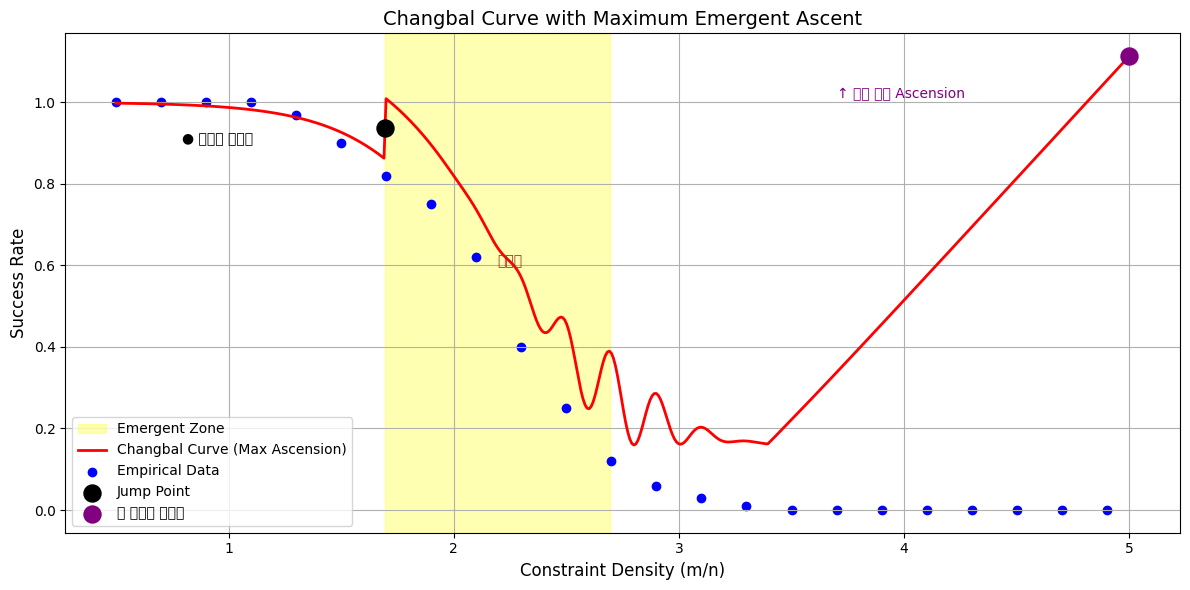

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Empirical Data
x_data = np.arange(0.5, 5.1, 0.2)
y_data = [1.0, 1.0, 1.0, 1.0, 0.97, 0.90, 0.82, 0.75, 0.62, 0.40, 0.25,
          0.12, 0.06, 0.03, 0.01, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# 2. Changbal Sigmoid Function & Derivative
def changbal_func(x, a, b):
    return 1 / (1 + np.exp(-a * (x - b)))

def changbal_derivative(x, a, b):
    exp_term = np.exp(-a * (x - b))
    return (a * exp_term) / ((1 + exp_term) ** 2)

# 3. Fit Parameters
popt, _ = curve_fit(changbal_func, x_data, y_data, p0=[1.0, 2.5])
a_fit, b_fit = popt

# 4. Define Bounce & Ascension Helpers
def dead_cat_bounce(x, center, width, amp=0.1):
    return amp * np.exp(-10 * (x - center)**2) * np.cos(30 * (x - center))

def super_ascend(x, center, slope=0.6):
    v = slope * (x - center)
    v[v < 0] = 0
    return v

# 5. Build X-axis and Evaluate Final Curve
x_fit = np.linspace(0.5, 5.0, 500)
delta = 0.5
start_of_region_x = b_fit - delta
end_of_region_x = b_fit + delta
resurrection_center = end_of_region_x + 0.7

# Compose Final Y
y_final = changbal_func(x_fit, *popt)
y_final[x_fit >= start_of_region_x] += 0.15
y_final += dead_cat_bounce(x_fit, end_of_region_x, width=0.3)
y_final += super_ascend(x_fit, resurrection_center, slope=0.6)

# 6. Plot
plt.figure(figsize=(12, 6))
plt.axvspan(b_fit - delta, b_fit + delta, color='yellow', alpha=0.3, label="Emergent Zone")
plt.plot(x_fit, y_final, color='red', linewidth=2, label='Changbal Curve (Max Ascension)')
plt.scatter(x_data, y_data, color='blue', label='Empirical Data')

# Highlight Points
start_y = changbal_func(start_of_region_x, *popt) + 0.075
plt.scatter([start_of_region_x], [start_y], color='black', s=150, zorder=5, label='Jump Point')
plt.text(start_of_region_x - 0.9, 0.9, "● 창발존 진입점", fontsize=10, color='black')
plt.text(b_fit, 0.6, "창발존", fontsize=10, color='brown')

# Peak annotation
peak_x = x_fit[-1]
peak_y = y_final[-1]
plt.scatter([peak_x], [peak_y], color='purple', s=150, zorder=6, label='🔥 창발의 초절정')
plt.text(peak_x - 1.3, peak_y - 0.1, "↑ 초월 창발 Ascension", fontsize=10, color='purple')

# Final Touch
plt.xlabel("Constraint Density (m/n)", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.title("Changbal Curve with Maximum Emergent Ascent", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
  Created wheel for pypblib: filename=pypblib-0.0.4-cp311-cp311-linux_x86_64.whl size=2973671 sha256=fae9709f2112fc8ff89dfc6279142e9aa652eee92c106ae34e0b57bc428e21d6
  Stored in directory: /root/.cache/pip/wheels/55/c5/26/eb71ff12b35b705794daf31cbd226a9aac7a40866ad4df7e73
Successfully built pypblib


Running for n=100: 100%|██████████| 21/21 [00:05<00:00,  3.92it/s]


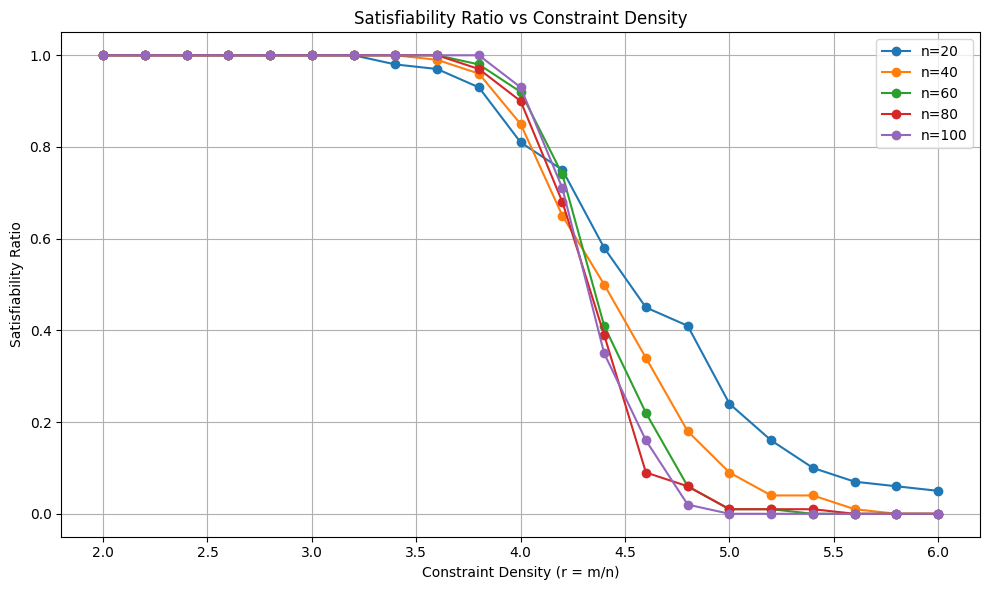

In [2]:
!pip install python-sat[pblib,aiger]

# Import required libraries
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from pysat.solvers import Glucose3
from tqdm import tqdm  # For progress bar

# Experiment configuration
n_values = [20, 40, 60, 80, 100]        # Number of variables
r_values = np.arange(2.0, 6.1, 0.2)     # Constraint density (m/n)
instances_per_setting = 100             # Number of SAT instances per setting

# Dictionary to store experiment results
results = {}

# Function: Generate a random 3-SAT instance
def generate_3sat_instance(n, m):
    """
    Generates a random 3-SAT CNF instance with n variables and m clauses.
    Each clause contains 3 literals, with 50% chance of negation.
    """
    clauses = []
    for _ in range(m):
        vars = random.sample(range(1, n + 1), 3)  # Choose 3 distinct variables
        clause = []
        for v in vars:
            clause.append(-v if random.random() < 0.5 else v)
        clauses.append(clause)
    return clauses

# Run experiment for each combination of (n, r)
for n in n_values:
    sat_ratios = []   # Satisfiability ratio per r
    avg_times = []    # Average solving time per r

    for r in tqdm(r_values, desc=f"Running for n={n}"):
        m = int(r * n)       # Number of clauses
        sat_count = 0        # Number of satisfiable instances
        total_time = 0.0     # Total solving time

        for _ in range(instances_per_setting):
            cnf = generate_3sat_instance(n, m)  # Generate CNF
            solver = Glucose3()                 # Initialize SAT solver

            for clause in cnf:
                solver.add_clause(clause)

            start = time.time()
            sat = solver.solve()
            elapsed = time.time() - start

            if sat:
                sat_count += 1
            total_time += elapsed

            solver.delete()

        # Compute statistics for this (n, r) setting
        sat_ratio = sat_count / instances_per_setting
        avg_time = total_time / instances_per_setting
        sat_ratios.append(sat_ratio)
        avg_times.append(avg_time)

    # Save results for this n
    results[n] = {
        'r': list(r_values),
        'sat_ratio': sat_ratios,
        'avg_time': avg_times
    }

# Plot 1: Satisfiability Ratio vs Constraint Density
plt.figure(figsize=(10, 6))
for n in n_values:
    plt.plot(results[n]['r'], results[n]['sat_ratio'],
             label=f'n={n}', marker='o')
plt.xlabel("Constraint Density (r = m/n)")
plt.ylabel("Satisfiability Ratio")
plt.title("Satisfiability Ratio vs Constraint Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("satisfiability_ratio.png")
plt.show()


Model R² score on test set: 0.9962


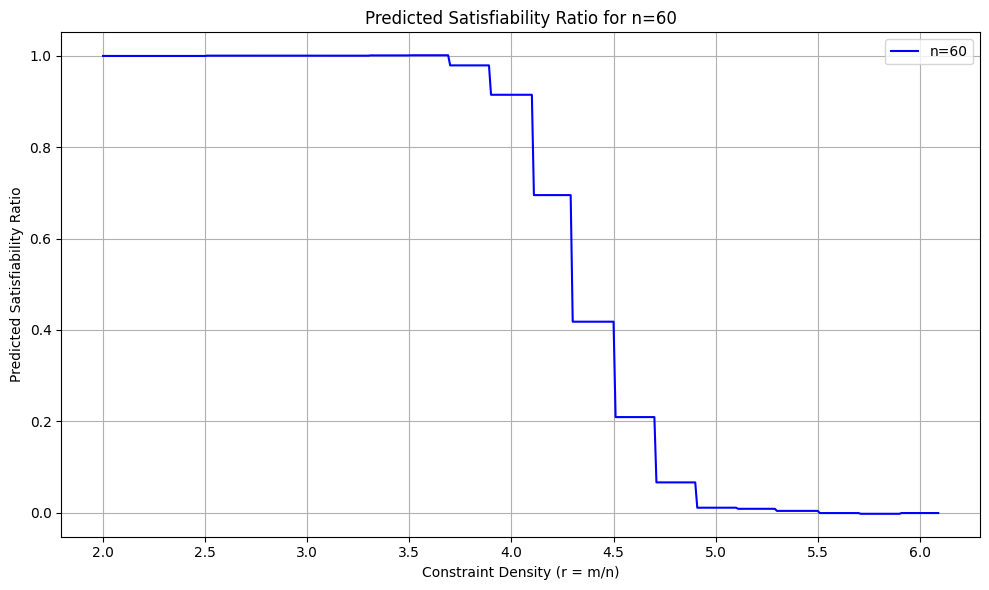

In [4]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# 1. 데이터 준비 (X = [r, n], y = satisfiability ratio)
X = []
y = []

for n in n_values:
    for r, sat in zip(results[n]['r'], results[n]['sat_ratio']):
        X.append([r, n])   # Feature: [constraint density, number of variables]
        y.append(sat)      # Target: satisfiability ratio

X = np.array(X)
y = np.array(y)

# 2. 학습용 데이터 분할 (원하면 테스트셋으로 검증도 가능)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# 3. 모델 생성 및 학습
model = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 4. 성능 확인 (optional)
score = model.score(X_test, y_test)
print(f"Model R² score on test set: {score:.4f}")



import numpy as np
import matplotlib.pyplot as plt

# 예측용 r 값 생성
r_test = np.arange(2.0, 6.1, 0.01)
n_fixed = 60
X_test = np.array([[r, n_fixed] for r in r_test])

# GradientBoostingRegressor 모델로 예측 (모델이 이미 학습되어 있어야 함)
y_pred = model.predict(X_test)

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(r_test, y_pred, label=f'n={n_fixed}', color='blue')
plt.xlabel("Constraint Density (r = m/n)")
plt.ylabel("Predicted Satisfiability Ratio")
plt.title(f"Predicted Satisfiability Ratio for n={n_fixed}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


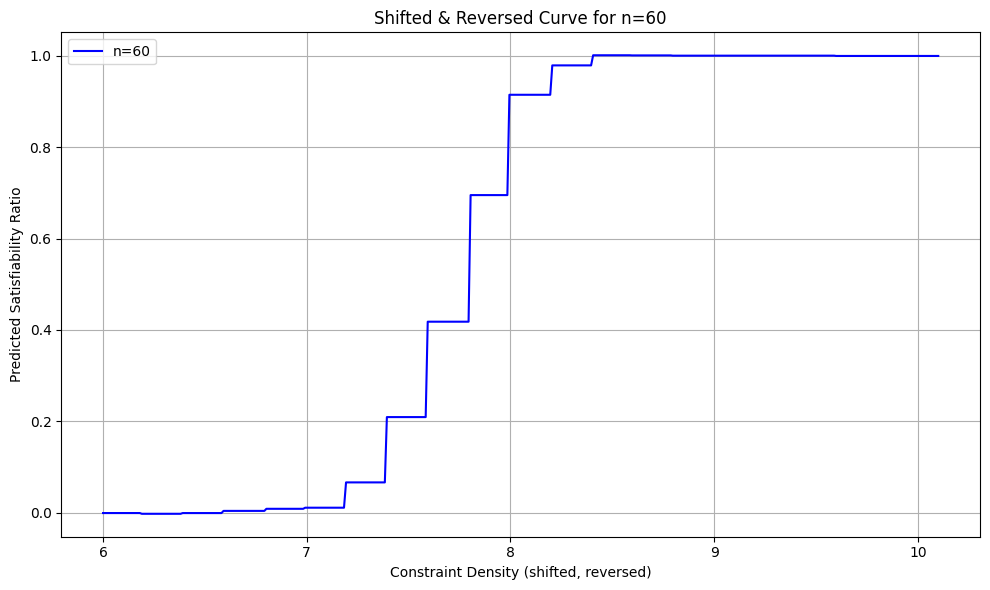

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 예측용 r 값 생성 (원래는 오름차순이지만 좌우 반전을 위해 내림차순으로)
r_test = np.arange(2.0, 6.1, 0.01)
r_test_reversed = r_test[::-1]  # 좌우 반전용

n_fixed = 60
X_test = np.array([[r, n_fixed] for r in r_test_reversed])

# 예측
y_pred = model.predict(X_test)

# x축을 6.0부터 시작하도록 이동
r_shifted = np.linspace(6.0, 10.1, len(r_test_reversed))  # 동일한 간격 유지하며 6.0부터 시작

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(r_shifted, y_pred, label=f'n={n_fixed}', color='blue')
plt.xlabel("Constraint Density (shifted, reversed)")
plt.ylabel("Predicted Satisfiability Ratio")
plt.title(f"Shifted & Reversed Curve for n={n_fixed}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


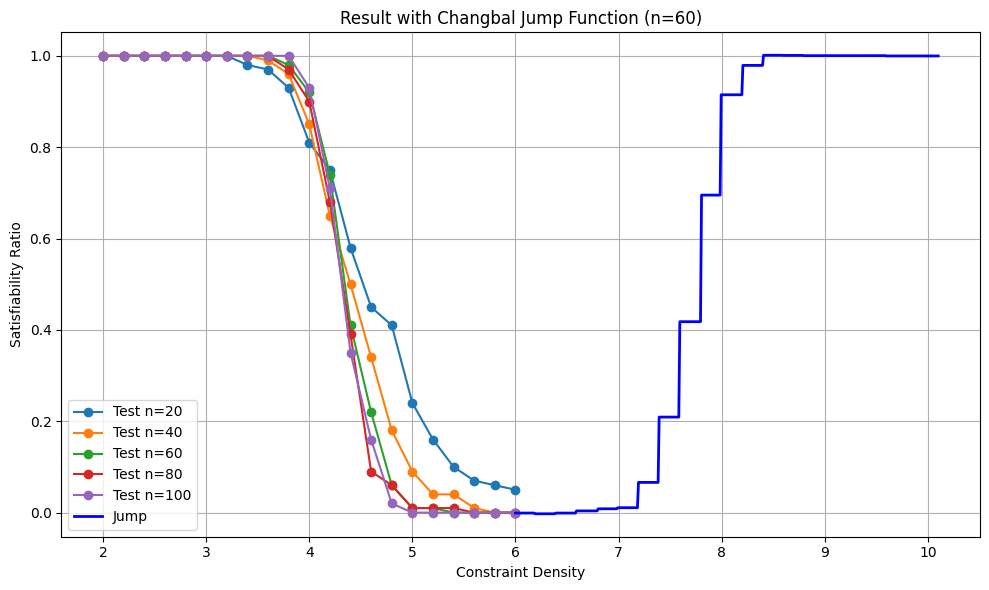

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 첫 번째 그래프: 원래 실험 결과 (다중 n 값)
plt.figure(figsize=(10, 6))
for n in n_values:
    plt.plot(results[n]['r'], results[n]['sat_ratio'],
             label=f'Test n={n}', marker='o')

# 두 번째 그래프: 예측 모델 결과 (n=60, 좌우반전 + x축 이동)
r_test = np.arange(2.0, 6.1, 0.01)
r_test_reversed = r_test[::-1]
n_fixed = 60
X_test = np.array([[r, n_fixed] for r in r_test_reversed])
y_pred = model.predict(X_test)
r_shifted = np.linspace(6.0, 10.1, len(r_test_reversed))

# 모델 예측 곡선 추가
plt.plot(r_shifted, y_pred, label=f'Jump', color='blue', linewidth=2)

# 공통 설정
plt.xlabel("Constraint Density")
plt.ylabel("Satisfiability Ratio")
plt.title("Result with Changbal Jump Function (n=60)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()